# TP1 — EDA & Preprocessing initial
## Fil rouge : Churn Predictor (Telco Customer Churn)

**Durée estimée : 1h15**

### 🎯 Objectifs d'apprentissage
À la fin de ce TP vous saurez :
- Charger et inspecter un dataset réel (types, valeurs manquantes, cardinalité).
- Détecter et corriger un piège classique de typage (`TotalCharges` stocké en string).
- Mener une EDA ciblée : distribution de la cible, variables numériques et catégorielles vs target.
- Construire un **split stratifié train / val / test** avant tout traitement (et comprendre pourquoi).

### 📦 Pré-requis
- Python 3.10+
- `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`
- Connexion internet (le dataset est chargé depuis GitHub)

### 📌 Contexte métier
Vous travaillez pour un opérateur télécom. Chaque mois, ~26 % des clients résilient. La direction veut un modèle qui identifie les clients à risque pour cibler une campagne de rétention. Avant de modéliser, on doit **comprendre la donnée**.


## 0. Setup

On importe les librairies et on fixe une seed pour la reproductibilité.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Chargement du dataset

Le dataset Telco Customer Churn est disponible publiquement. On le charge directement depuis GitHub.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/IBM/"
    "telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
)

df = pd.read_csv(DATA_URL)

print(f"Shape: {df.shape}")
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Premier regard

Avant toute analyse, on inspecte systématiquement :
- Les **types** de chaque colonne (`dtypes`)
- Les **valeurs manquantes** (`isna().sum()`)
- La **cardinalité** de chaque colonne (`nunique()`) — utile pour distinguer numérique / catégoriel / identifiant

⚠️ **Point de vigilance** : ne JAMAIS faire confiance aux types par défaut de pandas. Toujours vérifier.

In [3]:
df.info()

print("\n--- Missing values per column ---")
print(df.isna().sum())

print("\n--- Unique values per column (sorted asc) ---")
print(df.nunique().sort_values())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Le piège de `TotalCharges`

Regardez bien le résultat de `df.info()` à la cellule précédente. Vous devriez constater que **`TotalCharges` est de type `object`** alors qu'il devrait être numérique (c'est un montant en dollars).

Pourquoi ? Parce que certaines lignes contiennent une chaîne vide (`" "`) au lieu d'un nombre. C'est un bug classique de l'export.

🎯 **Tâche** :
1. Convertir `TotalCharges` en numérique avec `errors="coerce"` (ce qui transforme `" "` en `NaN`).
2. Compter combien de NaN apparaissent.
3. Inspecter ces lignes : qu'ont-elles de particulier ?
4. Décider d'une stratégie de remplissage.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(f"NaN count: {df['TotalCharges'].isna().sum()}")

nan_rows = df[df["TotalCharges"].isna()]
print(f"\n--- Rows with NaN TotalCharges ({len(nan_rows)}) ---")
nan_rows[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]


NaN count: 11

--- Rows with NaN TotalCharges (11) ---


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


💡 **Observation** : tous les clients avec `TotalCharges` manquant ont `tenure == 0`. Ce sont des nouveaux clients qui n'ont encore rien payé. La stratégie naturelle est de remplir avec **0**.

In [5]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

assert df["TotalCharges"].isna().sum() == 0
print("OK — no more NaN in TotalCharges")


OK — no more NaN in TotalCharges


## 4. Distribution de la cible

La variable cible est `Churn` (Yes/No). On veut savoir :
- Quel est le **taux de churn** global ?
- Le dataset est-il **équilibré** ?

Cela conditionne :
- Le choix des **métriques** (l'accuracy peut être trompeuse sur un dataset déséquilibré).
- La nécessité éventuelle de techniques de **rééquilibrage** (qu'on verra en S2).

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


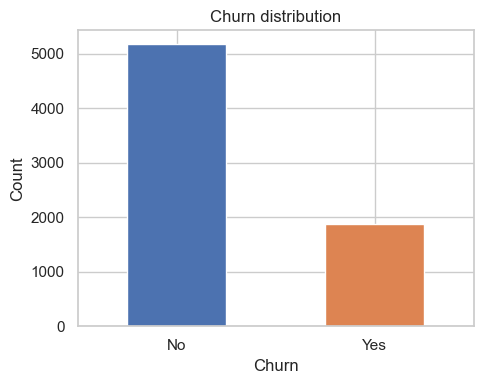

In [6]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)

churn_rate = (df["Churn"] == "Yes").mean()
print(f"\nChurn rate: {churn_rate:.2%}")

fig, ax = plt.subplots(figsize=(5, 4))
churn_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Churn distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 5. Variables numériques vs target

Les 3 colonnes numériques sont `tenure`, `MonthlyCharges`, `TotalCharges`. On veut voir si leur distribution diffère selon que le client churn ou non — c'est le premier signal de **pouvoir prédictif**.

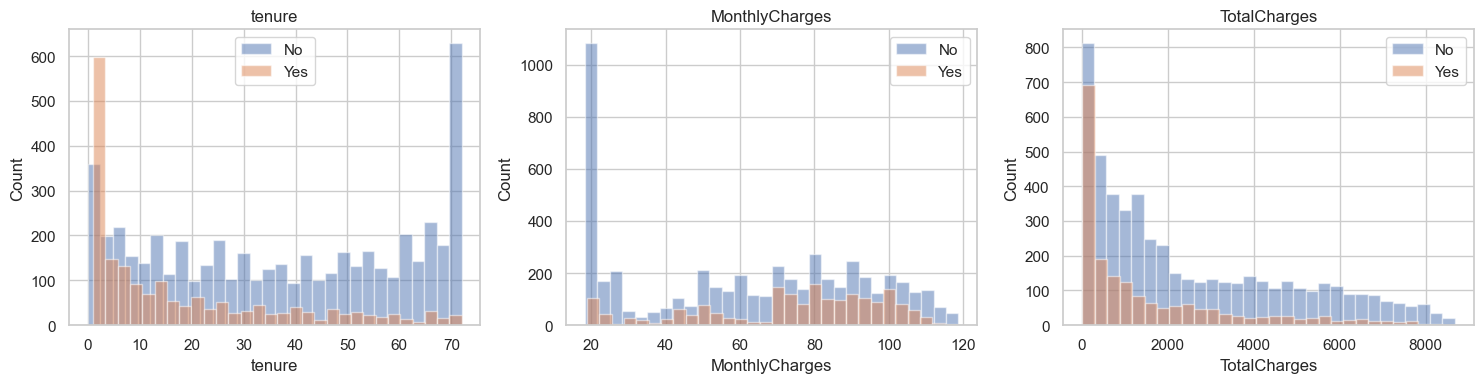

In [7]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df.loc[df["Churn"] == "No", col],
            bins=30, alpha=0.5, label="No", color="#4C72B0")
    ax.hist(df.loc[df["Churn"] == "Yes", col],
            bins=30, alpha=0.5, label="Yes", color="#DD8452")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()
plt.tight_layout()
plt.show()


💡 **Lecture rapide** :
- `tenure` : les churners ont des tenures plus courtes (départs précoces).
- `MonthlyCharges` : les churners paient plus cher par mois — hypothèse : facturation perçue comme excessive.
- `TotalCharges` : suit `tenure × MonthlyCharges` — corrélation attendue, à garder en tête pour la multicolinéarité.

## 6. Variables catégorielles vs target

Pour chaque colonne catégorielle, on calcule le **taux de churn par modalité**. Une grosse variation entre modalités = signal prédictif fort.

In [8]:
cat_cols = [c for c in df.columns
            if df[c].dtype == "object" and c not in ("customerID", "Churn")]
print(f"{len(cat_cols)} categorical columns: {cat_cols}")


def churn_rate_by(col: str) -> pd.Series:
    """Return churn rate per category of `col`, sorted descending."""
    return (
        df.assign(_churn=(df["Churn"] == "Yes").astype(int))
          .groupby(col)["_churn"]
          .mean()
          .sort_values(ascending=False)
    )


for col in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"\n--- Churn rate by {col} ---")
    print(churn_rate_by(col).map("{:.2%}".format))


15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

--- Churn rate by Contract ---
Contract
Month-to-month    42.71%
One year          11.27%
Two year           2.83%
Name: _churn, dtype: object

--- Churn rate by InternetService ---
InternetService
Fiber optic    41.89%
DSL            18.96%
No              7.40%
Name: _churn, dtype: object

--- Churn rate by PaymentMethod ---
PaymentMethod
Electronic check             45.29%
Mailed check                 19.11%
Bank transfer (automatic)    16.71%
Credit card (automatic)      15.24%
Name: _churn, dtype: object


💡 **Insights métier majeurs** :
- **Contract** : les `Month-to-month` churnent ~3 fois plus que les `Two year`. Logique : pas d'engagement = facilité de départ.
- **InternetService** : `Fiber optic` churn beaucoup plus que `DSL`. Hypothèse : prix perçu trop élevé pour la qualité.
- **PaymentMethod** : `Electronic check` est sur-représenté dans les churners. Hypothèse : signal de friction (paiement manuel mensuel).

🧠 **Réflexe Tech Lead** : ces insights ne sont pas que pour le modèle. Ils alimentent directement les décisions métier (changer la stratégie d'engagement, revoir le pricing fibre, pousser le prélèvement automatique).

## 7. Synthèse de votre EDA

🎯 **À faire** : remplissez la cellule markdown ci-dessous avec **3 à 5 hypothèses** que vous emportez de cette EDA. Une hypothèse = "tel signal devrait être utile au modèle parce que…".

> **Mes hypothèses :**
>
> 1. **`tenure` sera un prédicteur majeur** : la distribution montre une masse importante de churners en début de contrat (tenure faible). Plus un client est ancien, plus la probabilité qu'il reste est élevée — l'ancienneté capture la fidélité accumulée.
> 2. **`Contract` est probablement le signal catégoriel le plus fort** : le taux de churn des `Month-to-month` est ~3× celui des contrats annuels. C'est intuitif (pas d'engagement = friction de départ minimale) et ça se voit très clairement dans les `churn_rate_by`.
> 3. **`InternetService = Fiber optic` est un signal de risque** : le taux de churn y est très supérieur à `DSL` et surtout à `No internet`. Hypothèse business : prix de la fibre perçu comme excessif vs qualité de service ressentie.
> 4. **`PaymentMethod = Electronic check` capture une friction comportementale** : ces clients ont un taux de churn beaucoup plus élevé que les paiements automatiques (carte / virement). Le mode de paiement manuel est un signal indirect d'un engagement plus faible.
> 5. **`MonthlyCharges` élevé + `tenure` faible = combo à risque** : les nouveaux clients qui paient cher (souvent fibre + options) sont les plus susceptibles de partir — utile pour un modèle non linéaire qui capte cette interaction. Attention en revanche à la multicolinéarité `TotalCharges ≈ tenure × MonthlyCharges` pour les modèles linéaires.

## 8. Train / Validation / Test split

🚨 **Règle d'or** : on splitte **AVANT** tout traitement statistique sur la donnée (imputation, scaling, encoding). Sinon, on a une **fuite** depuis le test set vers le train set.

Le split classique :
- **Train (70 %)** : entraînement du modèle.
- **Validation (15 %)** : choix d'hyperparamètres, comparaison de modèles.
- **Test (15 %)** : score final, vu **une seule fois** à la fin du projet.

On utilise **`stratify=y`** pour conserver le taux de churn dans chaque split (sinon, on peut avoir un split de validation avec un taux de churn très différent, ce qui fausse l'évaluation).

In [9]:
X = df.drop(columns=["customerID", "Churn"])
y = (df["Churn"] == "Yes").astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print(f"Train: {len(X_train):>5} rows | churn rate: {y_train.mean():.2%}")
print(f"Val:   {len(X_val):>5} rows | churn rate: {y_val.mean():.2%}")
print(f"Test:  {len(X_test):>5} rows | churn rate: {y_test.mean():.2%}")


Train:  4930 rows | churn rate: 26.53%
Val:    1056 rows | churn rate: 26.52%
Test:   1057 rows | churn rate: 26.58%


## 9. Sauvegarde des splits

On persiste les splits sur disque pour pouvoir les recharger en TP2 sans tout refaire.

In [10]:
Path("data").mkdir(exist_ok=True)
X_train.to_csv("data/X_train.csv", index=False)
X_val.to_csv("data/X_val.csv", index=False)
X_test.to_csv("data/X_test.csv", index=False)
y_train.to_frame("Churn").to_csv("data/y_train.csv", index=False)
y_val.to_frame("Churn").to_csv("data/y_val.csv", index=False)
y_test.to_frame("Churn").to_csv("data/y_test.csv", index=False)
print("Splits saved to ./data/")


Splits saved to ./data/


## 🚀 Bonus (pour les rapides)

1. **Heatmap de corrélation** : encodez `Churn` en 0/1 et calculez la matrice de corrélation entre les colonnes numériques + churn binaire. Visualisez avec `sns.heatmap`.
2. **Pairplot ciblé** : faites un `sns.pairplot(df[num_cols + ["Churn"]], hue="Churn")` et commentez.
3. **Multicolinéarité** : `TotalCharges ≈ tenure × MonthlyCharges`. Calculez la corrélation. À votre avis, faut-il garder les 3 features ? Justifiez (indice : ça dépend du modèle).
4. **Catégorielles cachées** : certaines colonnes "object" ont 3 modalités dont `"No internet service"` ou `"No phone service"`. Sont-elles vraiment 3 modalités ou plutôt des doublons d'un autre signal ? Inspectez.

                tenure  MonthlyCharges  TotalCharges  Churn
tenure           1.000           0.248         0.826 -0.352
MonthlyCharges   0.248           1.000         0.651  0.193
TotalCharges     0.826           0.651         1.000 -0.198
Churn           -0.352           0.193        -0.198  1.000


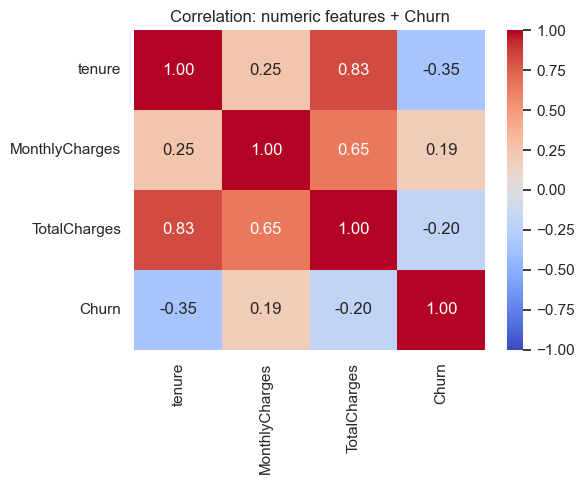

In [11]:
# Bonus 1 — Heatmap de corrélation
df_corr = df[num_cols].copy()
df_corr["Churn"] = (df["Churn"] == "Yes").astype(int)

corr = df_corr.corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation: numeric features + Churn")
plt.tight_layout()
plt.show()

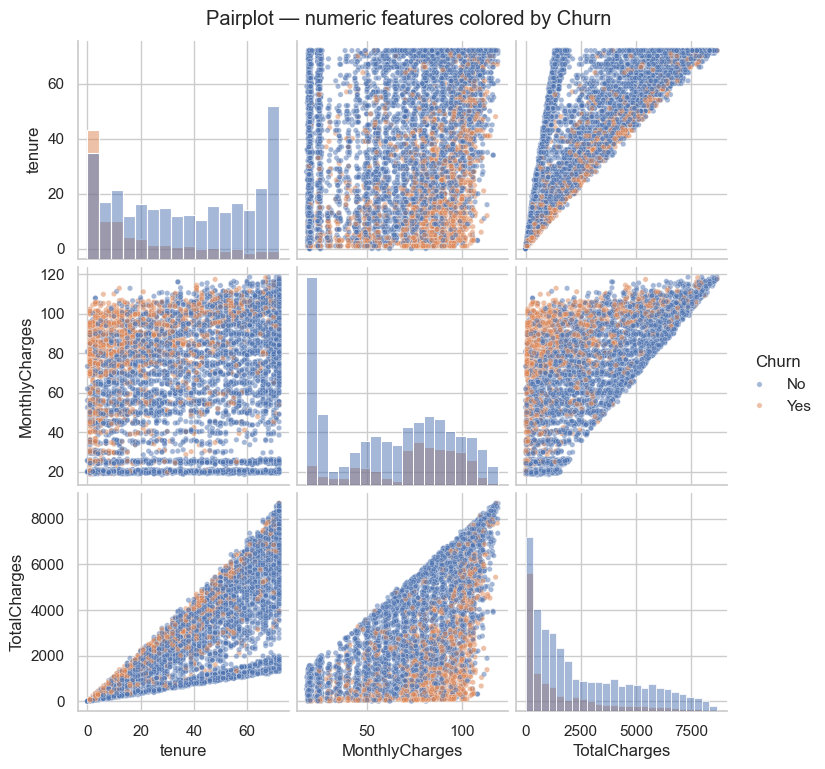

In [12]:
# Bonus 2 — Pairplot ciblé
sns.pairplot(df[num_cols + ["Churn"]], hue="Churn",
             plot_kws={"alpha": 0.5, "s": 15}, diag_kind="hist")
plt.suptitle("Pairplot — numeric features colored by Churn", y=1.02)
plt.show()

In [13]:
# Bonus 3 — Multicolinéarité TotalCharges vs tenure × MonthlyCharges
implied = df["tenure"] * df["MonthlyCharges"]
corr_implied = np.corrcoef(implied, df["TotalCharges"])[0, 1]
print(f"corr(tenure * MonthlyCharges, TotalCharges) = {corr_implied:.4f}")

print("\nCorrélations 2 à 2 :")
print(df[num_cols].corr().round(3))

corr(tenure * MonthlyCharges, TotalCharges) = 0.9996

Corrélations 2 à 2 :
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


**Faut-il garder les 3 features ?**

- **Modèles linéaires (régression logistique, linéaire)** : la quasi-colinéarité `TotalCharges ≈ tenure × MonthlyCharges` (corr ≈ 0.99) gonfle la variance des coefficients et rend leur interprétation instable. → On supprime généralement `TotalCharges`, ou on applique une régularisation (L2/L1).
- **Modèles à base d'arbres (Random Forest, XGBoost, LightGBM)** : la multicolinéarité ne pose pas de problème de stabilité. La feature redondante est juste rarement utilisée (importance partagée). → On peut tout garder, ça ne fait pas de mal.
- **Réseaux de neurones** : pas critique non plus, mais réduire la redondance améliore parfois la convergence.

**Verdict pragmatique** : on garde les 3 features dans le pipeline (pour ne pas perdre d'information), mais on retient que pour un modèle linéaire on devra réfléchir à `TotalCharges`.

In [14]:
# Bonus 4 — Catégorielles "cachées"
internet_dependent = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
phone_dependent = ["MultipleLines"]

print("--- Colonnes liées à InternetService ---")
for col in internet_dependent:
    print(f"\n{col}: {df[col].unique().tolist()}")
    crosstab = pd.crosstab(df["InternetService"], df[col])
    print(crosstab)

print("\n\n--- Colonnes liées à PhoneService ---")
for col in phone_dependent:
    print(f"\n{col}: {df[col].unique().tolist()}")
    crosstab = pd.crosstab(df["PhoneService"], df[col])
    print(crosstab)

--- Colonnes liées à InternetService ---

OnlineSecurity: ['No', 'Yes', 'No internet service']
OnlineSecurity     No  No internet service   Yes
InternetService                                 
DSL              1241                    0  1180
Fiber optic      2257                    0   839
No                  0                 1526     0

OnlineBackup: ['Yes', 'No', 'No internet service']
OnlineBackup       No  No internet service   Yes
InternetService                                 
DSL              1335                    0  1086
Fiber optic      1753                    0  1343
No                  0                 1526     0

DeviceProtection: ['No', 'Yes', 'No internet service']
DeviceProtection    No  No internet service   Yes
InternetService                                  
DSL               1356                    0  1065
Fiber optic       1739                    0  1357
No                   0                 1526     0

TechSupport: ['No', 'Yes', 'No internet service']
TechSu

**Observation** : les modalités `"No internet service"` (dans `OnlineSecurity`, `OnlineBackup`, ...) et `"No phone service"` (dans `MultipleLines`) ne sont **pas de vraies modalités** — elles sont entièrement redondantes avec `InternetService == "No"` et `PhoneService == "No"` respectivement.

**Conséquence pour le preprocessing (TP2)** :
- On peut **remapper** `"No internet service" → "No"` (et idem pour `"No phone service" → "No"`) pour passer ces colonnes en binaire propre.
- Sinon, le one-hot encoding va créer une colonne dummy qui est une copie exacte de `InternetService_No` → bruit + multicolinéarité parfaite.

Réflexe à retenir : toujours **croiser les modalités catégorielles entre elles** quand le nombre de modalités semble "louche".